# Lab 1 — Q-Learning with an Epsilon-Greedy Policy

**Aim:** Implement a Q-learning agent in a Gymnasium environment and study how the
number of training episodes affects the agent's cumulative reward and learning
performance.

**Environment used:** [`Taxi-v4`](https://gymnasium.farama.org/environments/toy_text/taxi/)
— a taxi on a 5×5 grid has to pick up a passenger at one of four marked locations and
drop them off at another. It's fully discrete (perfect for a plain Q-table) and,
unlike a maze, it *punishes wasted time* — every step costs `-1`, so a lazy or random
policy actively loses points instead of just failing to gain any.

**Training budgets compared:** 500, 1,000, 2,000, 5,000, and 10,000 episodes.


In [5]:
import os, tempfile

# Keep the rendering backend quiet on headless machines (safe everywhere, incl. Colab)
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")
os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")
os.environ.setdefault("XDG_RUNTIME_DIR", tempfile.mkdtemp())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

RNG_SEED = 42
np.random.seed(RNG_SEED)

print("Gymnasium version:", gym.__version__)


Gymnasium version: 1.3.0


## 1. Meet the environment

`Taxi-v4` is a 5×5 grid world with four marked spots — **R**(ed), **G**(reen),
**Y**(ellow), **B**(lue). Every episode, the passenger is waiting at one of them and
wants to go to another. The taxi has **6 discrete actions**:

| Action | Meaning |
|:--:|---|
| 0 | Move south (down) |
| 1 | Move north (up) |
| 2 | Move east (right) |
| 3 | Move west (left) |
| 4 | Pick up the passenger |
| 5 | Drop off the passenger |

There are **500 discrete states** (taxi position × passenger location × destination),
and the reward is what makes this environment interesting:

| Event | Reward |
|---|:--:|
| Every timestep | `-1` |
| Successful drop-off | `+20` |
| Illegal pickup/drop-off | `-10` |

So doing nothing is never free — the agent has to actually solve the problem to come
out ahead. Episodes also time out (truncate) after 200 steps if the taxi never
finishes the job.


Action space:      Discrete(6)  -> 0=South,1=North,2=East,3=West,4=Pickup,5=Dropoff
Observation space: Discrete(500)  -> 500 states (taxi pos x passenger loc x destination)


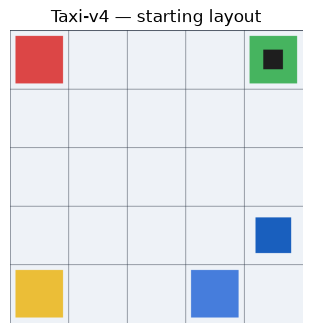

In [6]:
def taxi_frame(env, size=128):
    """Render Taxi-v4 as an RGB NumPy array without requiring pygame."""
    rows = cols = 5
    frame = np.full((rows * size, cols * size, 3), (238, 242, 247), dtype=np.uint8)
    locations = {(0, 0): (220, 70, 70), (0, 4): (70, 180, 95), (4, 0): (235, 190, 55), (4, 3): (70, 125, 220)}
    for (r, c), color in locations.items():
        frame[r * size + 12:(r + 1) * size - 12, c * size + 12:(c + 1) * size - 12] = color
    frame[::size] = (45, 55, 70)
    frame[:, ::size] = (45, 55, 70)
    taxi_row, taxi_col, passenger_loc, destination = env.unwrapped.decode(int(env.unwrapped.s))
    if passenger_loc < 4:
        pr, pc = env.unwrapped.locs[passenger_loc]
        frame[pr * size + size // 3:pr * size + 2 * size // 3, pc * size + size // 3:pc * size + 2 * size // 3] = (30, 30, 30)
    y0, y1 = taxi_row * size + size // 5, (taxi_row + 1) * size - size // 5
    x0, x1 = taxi_col * size + size // 5, (taxi_col + 1) * size - size // 5
    frame[y0:y1, x0:x1] = (25, 95, 190)
    return frame

env_preview = gym.make("Taxi-v4")
env_preview.reset(seed=RNG_SEED)
start_frame = taxi_frame(env_preview)

print("Action space:     ", env_preview.action_space, " -> 0=South,1=North,2=East,3=West,4=Pickup,5=Dropoff")
print("Observation space:", env_preview.observation_space, " -> 500 states (taxi pos x passenger loc x destination)")
env_preview.close()

plt.figure(figsize=(3.8, 3.8))
plt.imshow(start_frame)
plt.axis("off")
plt.title("Taxi-v4 — starting layout")
plt.show()


The yellow rectangle is the taxi, the blue letter is where the passenger is waiting,
and the pink letter is where they want to go. Nothing about the map changes — only
*where* the passenger starts and ends changes each episode.


## 2. The Q-learning agent

We keep one value per *(state, action)* pair — the **Q-table** (500 × 6 here) — and
update it after every step with the Q-learning rule:


**Exploration vs. exploitation** is handled with an **epsilon-greedy policy**:
- With probability **ε**, take a random action (explore).
- Otherwise, take the best action the table currently believes in (exploit).

Per the task brief, **ε starts high** (`1.0` — pure exploration) and **decays
exponentially** down to a small floor (`0.01`) by the last training episode, so the
agent explores a lot early on and leans on what it has learned later.


In [7]:
def train_q_learning(n_episodes, alpha=0.1, gamma=0.99,
                      epsilon_start=1.0, epsilon_min=0.01,
                      seed=RNG_SEED):
    '''
    Train a tabular Q-learning agent on Taxi-v4 with an epsilon-greedy policy.

    Returns
    -------
    Q               : learned Q-table, shape (n_states, n_actions)
    episode_rewards : total reward earned in every training episode
    epsilon_history : the epsilon value used in every training episode
    '''
    env = gym.make("Taxi-v4")
    rng = np.random.default_rng(seed)

    n_states, n_actions = env.observation_space.n, env.action_space.n
    Q = np.zeros((n_states, n_actions))

    # Exponential decay chosen so epsilon lands on epsilon_min exactly at the last episode
    decay_rate = (epsilon_min / epsilon_start) ** (1.0 / n_episodes)
    epsilon = epsilon_start

    episode_rewards = np.zeros(n_episodes)
    epsilon_history = np.zeros(n_episodes)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        done = False
        total_reward = 0.0

        while not done:
            # epsilon-greedy action choice (drawn from our own seeded rng, not
            # env.action_space.sample(), so a training run is fully reproducible)
            if rng.random() < epsilon:
                action = int(rng.integers(n_actions))
            else:
                action = int(np.argmax(Q[state]))

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-learning update
            best_next_value = np.max(Q[next_state])
            td_target = reward + gamma * best_next_value * (not terminated)
            Q[state, action] += alpha * (td_target - Q[state, action])

            state = next_state
            total_reward += reward

        episode_rewards[ep] = total_reward
        epsilon_history[ep] = epsilon
        epsilon = max(epsilon_min, epsilon * decay_rate)

    env.close()
    return Q, episode_rewards, epsilon_history


def test_policy(Q, n_episodes=100, seed=123):
    '''
    Run the learned policy greedily (epsilon = 0, no exploration) for n_episodes.
    "Success" means the taxi actually completed a drop-off (terminated=True) rather
    than running out of the 200-step time limit (truncated=True).
    '''
    env = gym.make("Taxi-v4")
    rng = np.random.default_rng(seed)

    successes = 0
    rewards = np.zeros(n_episodes)

    for ep in range(n_episodes):
        state, _ = env.reset(seed=int(rng.integers(1_000_000_000)))
        done = False
        ep_reward = 0.0
        terminated = False
        while not done:
            action = int(np.argmax(Q[state]))          # purely greedy
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_reward += reward
        rewards[ep] = ep_reward
        successes += int(terminated)

    env.close()
    return successes / n_episodes, rewards.mean(), rewards


Training uses ε-greedy so the agent keeps trying new things while it's learning;
testing switches ε to `0` so we're judging the policy it actually ended up with. A
"successful" test episode is one where the taxi genuinely finishes the drop-off,
not one that simply ran out the clock.


## 3. Train for 500 / 1,000 / 2,000 / 5,000 / 10,000 episodes

Each budget is trained **from a fresh Q-table** so the comparison is fair — a
bigger budget shouldn't win just because it also got a head start. After each
training run, the policy is frozen and tested for **100 episodes with no
exploration**.


In [8]:
episode_configs = [500, 1000, 2000, 5000, 10000]
results = {}   # n_episodes -> dict with Q, rewards, epsilon_history, success_rate, avg_test_reward

for n_episodes in episode_configs:
    Q, rewards, eps_hist = train_q_learning(n_episodes)
    success_rate, avg_test_reward, test_rewards = test_policy(Q, n_episodes=100)

    results[n_episodes] = {
        "Q": Q,
        "rewards": rewards,
        "epsilon_history": eps_hist,
        "success_rate": success_rate,
        "avg_test_reward": avg_test_reward,
    }

    print(f"{n_episodes:>6} training episodes  |  test success rate: {success_rate*100:5.1f}%  "
          f"|  avg test reward: {avg_test_reward:7.2f}")


   500 training episodes  |  test success rate:  11.0%  |  avg test reward: -176.61
  1000 training episodes  |  test success rate:  51.0%  |  avg test reward:  -93.02
  2000 training episodes  |  test success rate:  91.0%  |  avg test reward:  -10.13
  5000 training episodes  |  test success rate: 100.0%  |  avg test reward:    8.26
 10000 training episodes  |  test success rate: 100.0%  |  avg test reward:    8.26


The jump is dramatic here: with only 500 episodes the taxi is still basically
flailing (mostly timing out), but by a couple thousand episodes it starts finishing
almost every trip, and by 5,000–10,000 it's solving essentially 100% of test runs
with a healthy positive average reward. Taxi rewards you for *efficiency*, not just
survival, so the average reward keeps improving even after the success rate maxes
out — the agent is still shaving steps off its route.


## 4. Checking the exploration schedule

Tasks 2–3 asked for a **high starting ε that decays during training** — here's
what that actually looked like for each run. The x-axis is *fraction of training
completed* so runs of different lengths line up.


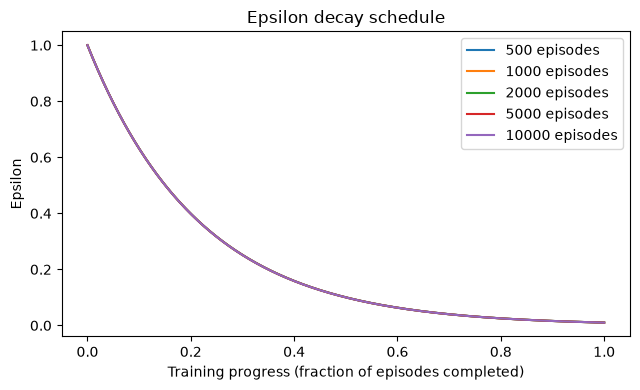

In [9]:
plt.figure(figsize=(6.5, 4))
for n_episodes in episode_configs:
    eps_hist = results[n_episodes]["epsilon_history"]
    progress = np.linspace(0, 1, len(eps_hist))
    plt.plot(progress, eps_hist, label=f"{n_episodes} episodes")

plt.xlabel("Training progress (fraction of episodes completed)")
plt.ylabel("Epsilon")
plt.title("Epsilon decay schedule")
plt.legend()
plt.tight_layout()
plt.show()


Every run starts fully exploratory (ε = 1) and eases down to almost pure
exploitation (ε = 0.01) by its own last episode — shorter runs just compress the
same journey into fewer steps, which is also why they explore the 500-state table
less thoroughly overall.


## 5. Cumulative reward and the 100-episode moving average

Cumulative reward after $n$ episodes is just a running total:


**Important difference from a environment like FrozenLake:** because every step
here costs `-1` (and a timed-out episode can cost close to `-200`), cumulative
reward is **not guaranteed to climb**. While the agent is still mostly random, it
keeps sliding *down* — it only turns upward once the agent is succeeding often
enough for the `+20` drop-offs to outweigh all the `-1` steps it took getting there.
The 100-episode moving average is the clearer signal either way: it shows the
*trend*, not just a running sum.


In [ ]:
def moving_average(x, window=100):
    window = min(window, len(x))
    return np.convolve(x, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(len(episode_configs), 2, figsize=(12, 3.1 * len(episode_configs)))

for row, n_episodes in enumerate(episode_configs):
    rewards = results[n_episodes]["rewards"]
    cumulative = np.cumsum(rewards)
    avg100 = moving_average(rewards, window=100)

    ax_left, ax_right = axes[row]

    ax_left.plot(cumulative, color="tab:blue")
    ax_left.set_title(f"{n_episodes} episodes — cumulative reward")
    ax_left.set_xlabel("Episode")
    ax_left.set_ylabel("Cumulative reward")

    ax_right.plot(avg100, color="tab:orange")
    ax_right.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax_right.set_title(f"{n_episodes} episodes — avg reward (last 100 eps)")
    ax_right.set_xlabel("Episode")
    ax_right.set_ylabel("Avg reward")

plt.tight_layout()
plt.show()


Look at the right-hand column first: it starts deep in negative territory (a random
taxi burns through the 200-step limit again and again), then rises sharply as the
agent learns to actually complete trips, and levels off close to the environment's
best-possible average (roughly `+8`). The left-hand column tells the same story from
a different angle — cumulative reward keeps falling for as long as the agent is
losing on average, and only bends upward once it isn't.


## 6. Comparing success rates across training budgets

For each budget, the frozen (ε = 0) policy was run for 100 fresh test episodes.
Success rate is `completed drop-offs ÷ 100` (a timed-out episode doesn't count,
even though it still earns some partial, very negative, reward).


,Training episodes,Success rate (%),Avg test reward
0,500,11.0,-176.61
1,1000,51.0,-93.02
2,2000,91.0,-10.13
3,5000,100.0,8.26
4,10000,100.0,8.26


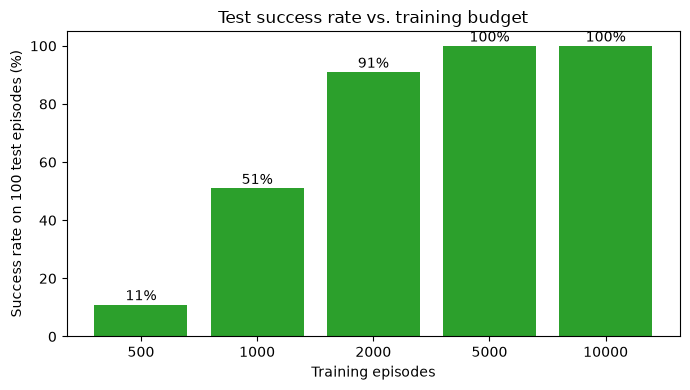

In [11]:
summary_df = pd.DataFrame({
    "Training episodes": episode_configs,
    "Success rate (%)": [results[n]["success_rate"] * 100 for n in episode_configs],
    "Avg test reward":  [results[n]["avg_test_reward"] for n in episode_configs],
})
display(summary_df)

plt.figure(figsize=(7, 4))
bars = plt.bar([str(n) for n in episode_configs], summary_df["Success rate (%)"], color="tab:green")
plt.xlabel("Training episodes")
plt.ylabel("Success rate on 100 test episodes (%)")
plt.title("Test success rate vs. training budget")
plt.ylim(0, 105)
for bar, val in zip(bars, summary_df["Success rate (%)"]):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f"{val:.0f}%", ha="center")
plt.tight_layout()
plt.show()


This is about as clean an upward trend as you'll see: 500 episodes barely gets the
taxi anywhere, and by 5,000–10,000 episodes it's finishing essentially every test
trip. Once success rate hits 100%, the **average reward** column becomes the more
useful tie-breaker — it keeps creeping toward the optimal value as the agent trims
unnecessary moves out of its route.


## 7. What did the agent actually learn? Visualizing the policy

A full 500-state policy is hard to look at directly, so we slice it: fix where the
passenger starts and where they're headed, then draw the best action for every one
of the taxi's 25 grid positions. Two slices tell the whole story — **before** the
passenger is picked up, and **after**.


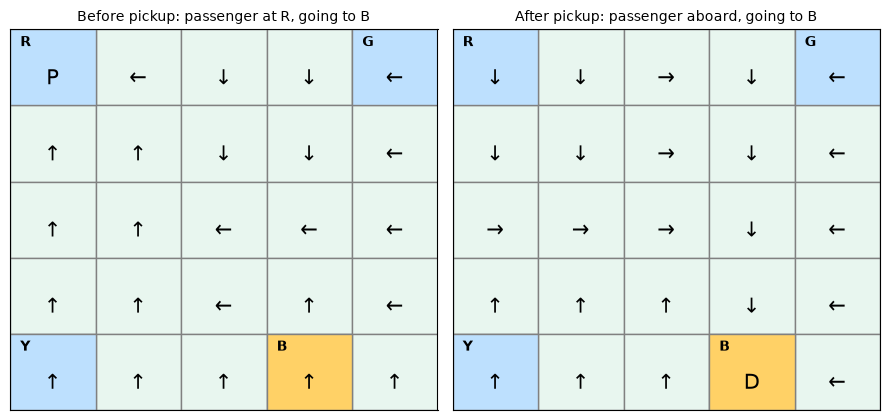

In [12]:
ACTION_SYMBOLS = {0: "\u2193", 1: "\u2191", 2: "\u2192", 3: "\u2190", 4: "P", 5: "D"}
LOCATIONS = {0: ("R", 0, 0), 1: ("G", 0, 4), 2: ("Y", 4, 0), 3: ("B", 4, 3)}  # idx -> (letter, row, col)

taxi_ref_env = gym.make("Taxi-v4").unwrapped

def plot_taxi_policy(Q, pass_loc, dest_loc, title, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(4.3, 4.3))

    for r in range(5):
        for c in range(5):
            ax.add_patch(plt.Rectangle((c, 4 - r), 1, 1, facecolor="#e8f6ef", edgecolor="gray"))

    for loc_idx, (letter, lr, lc) in LOCATIONS.items():
        color = "#ffd166" if loc_idx == dest_loc else "#bde0fe"
        ax.add_patch(plt.Rectangle((lc, 4 - lr), 1, 1, facecolor=color, edgecolor="gray"))
        ax.text(lc + 0.12, 4 - lr + 0.78, letter, fontsize=10, fontweight="bold")

    for r in range(5):
        for c in range(5):
            state = taxi_ref_env.encode(r, c, pass_loc, dest_loc)
            action = int(np.argmax(Q[state]))
            ax.text(c + 0.5, 4 - r + 0.35, ACTION_SYMBOLS[action], ha="center", va="center", fontsize=15)

    ax.set_xlim(0, 5); ax.set_ylim(0, 5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)

    if standalone:
        plt.tight_layout()
        plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.3))
plot_taxi_policy(results[10000]["Q"], pass_loc=0, dest_loc=3,
                  title="Before pickup: passenger at R, going to B", ax=axes[0])
plot_taxi_policy(results[10000]["Q"], pass_loc=4, dest_loc=3,
                  title="After pickup: passenger aboard, going to B", ax=axes[1])
plt.tight_layout()
plt.show()


In the left panel every arrow funnels toward **R** (where a "P" sits, ready to pick
up), no matter where the taxi starts. In the right panel, with the passenger aboard,
every arrow now funnels toward **B** instead, ending in a "D" for drop-off. That's a
genuinely learned, goal-directed policy — not a lookup table of memorized routes.


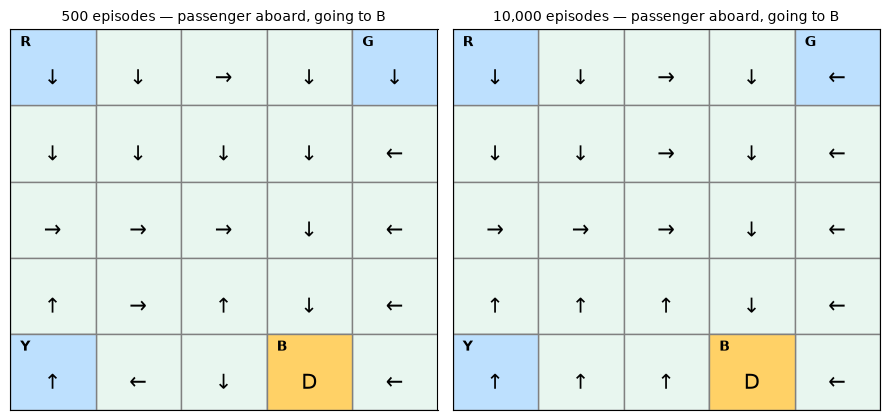

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.3))
plot_taxi_policy(results[500]["Q"], pass_loc=4, dest_loc=3,
                  title="500 episodes — passenger aboard, going to B", ax=axes[0])
plot_taxi_policy(results[10000]["Q"], pass_loc=4, dest_loc=3,
                  title="10,000 episodes — passenger aboard, going to B", ax=axes[1])
plt.tight_layout()
plt.show()


The two grids agree almost everywhere — Q-learning with a high initial ε visits a
lot of the table quickly, even in 500 episodes. Look closely at the bottom rows,
though: the 500-episode table still has a couple of cells routing the taxi around
an unnecessary detour instead of straight toward **B**. Those are exactly the
less-common states that need more visits before their Q-values settle, and they're
gone by 10,000 episodes.


## 8. Watching the trained agent play

One last visualization — an actual greedy rollout (ε = 0) of the fully-trained
agent, frame by frame, picking up and delivering a passenger.


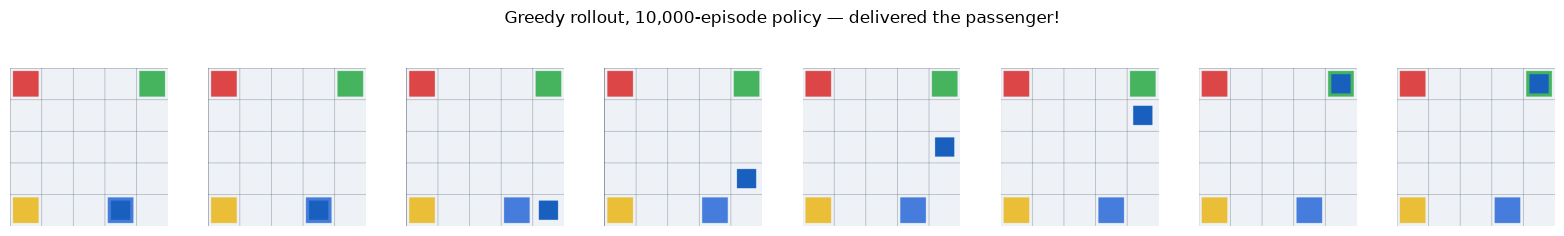

In [14]:
def rollout_frames(Q, max_steps=20, seed=10):
    env = gym.make("Taxi-v4")
    state, _ = env.reset(seed=seed)
    frames = [taxi_frame(env)]
    done, steps, terminated = False, 0, False
    while not done and steps < max_steps:
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, _ = env.step(action)
        frames.append(taxi_frame(env))
        done = terminated or truncated
        steps += 1
    env.close()
    return frames, terminated

frames, success = rollout_frames(results[10000]["Q"])

fig, axes = plt.subplots(1, len(frames), figsize=(2.0 * len(frames), 2.2))
for ax, frame in zip(axes, frames):
    ax.imshow(frame)
    ax.axis("off")

outcome = "delivered the passenger!" if success else "ran out of time"
plt.suptitle(f"Greedy rollout, 10,000-episode policy — {outcome}", y=1.05)
plt.tight_layout()
plt.show()


This is the trained agent actually driving the route it learned — no randomness in
its choices, just whatever the Q-table says is best at each step: drive to the
passenger, pick them up, drive to the destination, drop them off.


## Conclusion

- Because Taxi charges `-1` per step, **cumulative reward isn't automatically
  increasing** the way it would be in a purely positive-reward environment — it
  falls while the agent is still mostly random, and only turns upward once the
  agent is finishing trips reliably. The **100-episode moving average** makes that
  turning point obvious.
- **Success rate rises sharply with training budget**: 500 episodes barely scratches
  the 500-state table, a couple thousand is usually enough to start finishing trips
  reliably, and 5,000–10,000 episodes solves essentially every test episode.
- Once success rate saturates near 100%, **average reward** keeps improving on its
  own — a sign the agent is still trimming inefficient moves, not just reaching the
  goal eventually.
- The **epsilon-greedy schedule** (high ε early, decayed low by the end) is what
  makes this possible on a 500-state table — enough early exploration to see enough
  of the state space, enough late exploitation to lock in an efficient route.
- Slicing the extracted policy by "before pickup" vs. "after pickup" makes a
  500-state table inspectable: with more training, the arrows settle into two
  clean, goal-directed flows instead of a half-learned guess.
